In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import torch
print("GPU:", torch.cuda.is_available())

GPU: True


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. ResNET
def get_resnet_model(num_classes=102):
    model = models.resnet50(weights='IMAGENET1K_V1')
    num_ftrs = model.fc.in_features
    # Output_layer
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

model = get_resnet_model()

# 3. Loss function (Ablation: Adam vs SGD)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 223MB/s]


In [21]:
import torch.optim as optim

def train_ablation_model(model, train_loader, optimizer, epochs=5):
    criterion = torch.nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{epochs}] complete")
    return model

=== Baseline: 128x128 + Adam Optimizer ===
Epoch [1/5] complete
Epoch [2/5] complete
Epoch [3/5] complete
Epoch [4/5] complete
Epoch [5/5] complete


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.37      0.51      0.43        70
           1       1.00      1.00      1.00        66
           2       1.00      1.00      1.00        66
           3       1.00      1.00      1.00        30
           4       0.99      1.00      1.00       120
           5       1.00      0.62      0.77         8
           6       0.98      1.00      0.99       120
           7       0.00      0.00      0.00         6
           8       0.50      0.17      0.25         6
           9       1.00      0.57      0.73         7
          10       1.00      0.12      0.22         8
          11       1.00      0.14      0.25         7
          12       0.57      0.80      0.67         5
          13       0.32      1.00      0.48        19
          14       0.90      0.60      0.72        15
          15       1.00      0.57      0.73         7
          16       0.73      0.85      0.79        13
          17       0.78    

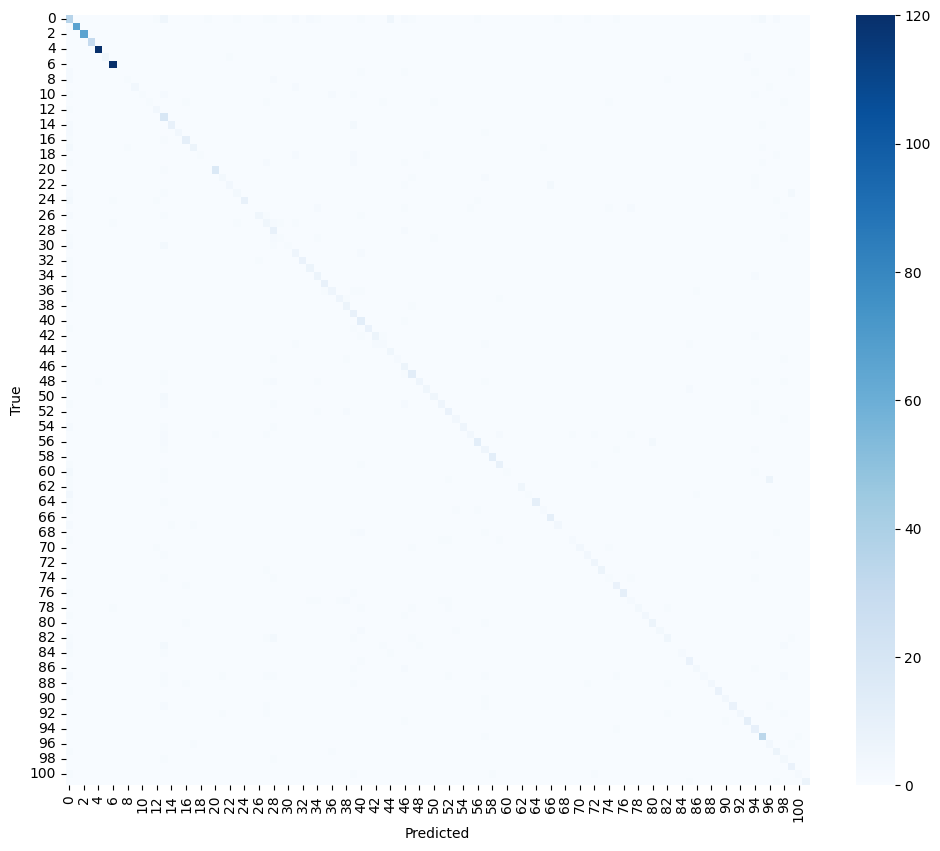


=== Ablation 1: 128x128 + SGD Optimizer ===
Epoch [1/5] complete
Epoch [2/5] complete
Epoch [3/5] complete
Epoch [4/5] complete
Epoch [5/5] complete
              precision    recall  f1-score   support

           0       0.79      0.84      0.81        70
           1       1.00      1.00      1.00        66
           2       1.00      1.00      1.00        66
           3       1.00      1.00      1.00        30
           4       0.99      1.00      1.00       120
           5       1.00      1.00      1.00         8
           6       0.99      1.00      1.00       120
           7       0.83      0.83      0.83         6
           8       0.71      0.83      0.77         6
           9       1.00      1.00      1.00         7
          10       0.78      0.88      0.82         8
          11       0.62      0.71      0.67         7
          12       1.00      0.80      0.89         5
          13       1.00      1.00      1.00        19
          14       0.93      0.93      

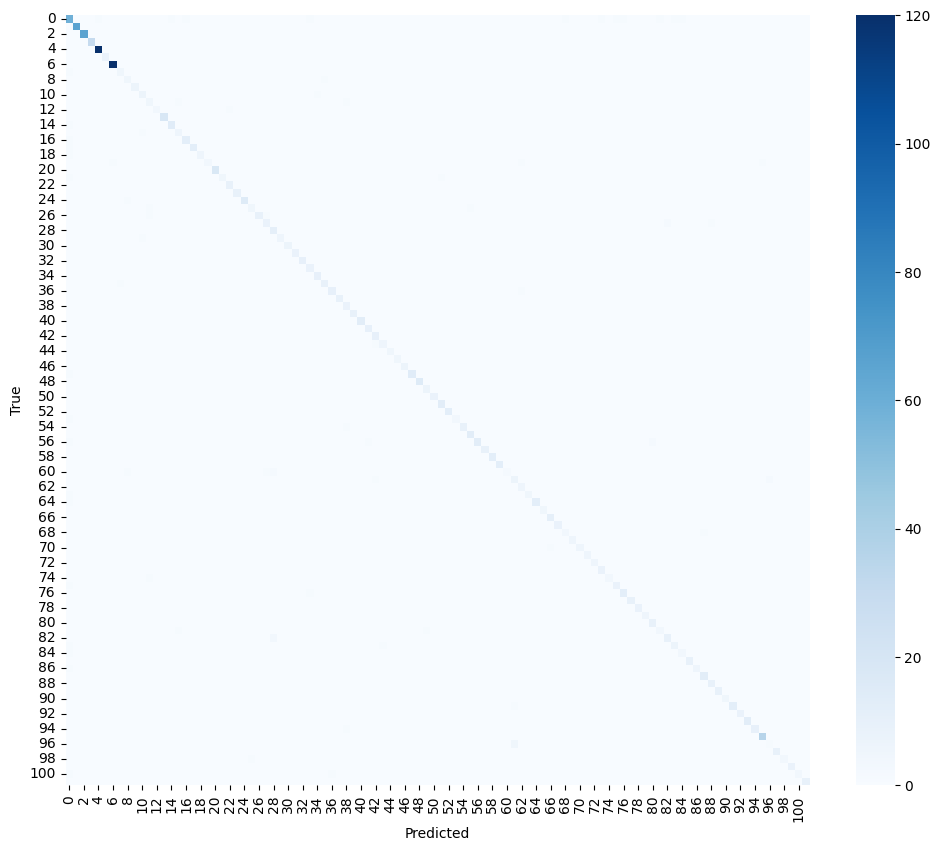


=== Ablation 2: 64x64 + Adam Optimizer ===
Epoch [1/5] complete
Epoch [2/5] complete
Epoch [3/5] complete
Epoch [4/5] complete
Epoch [5/5] complete


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.34      0.57      0.43        70
           1       0.97      1.00      0.99        66
           2       0.99      1.00      0.99        66
           3       1.00      1.00      1.00        30
           4       0.95      0.99      0.97       120
           5       0.86      0.75      0.80         8
           6       0.95      0.96      0.95       120
           7       0.20      0.17      0.18         6
           8       0.00      0.00      0.00         6
           9       0.57      0.57      0.57         7
          10       0.60      0.38      0.46         8
          11       0.30      0.43      0.35         7
          12       0.43      0.60      0.50         5
          13       0.90      0.95      0.92        19
          14       1.00      0.40      0.57        15
          15       0.60      0.43      0.50         7
          16       0.78      0.54      0.64        13
          17       0.45    

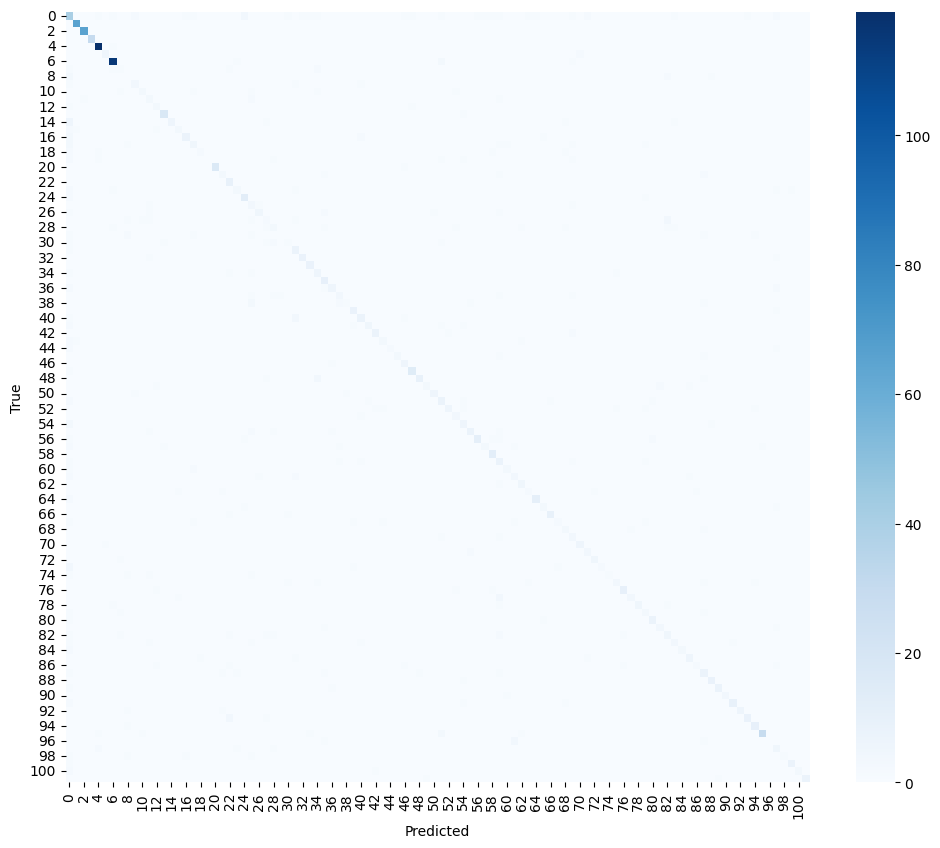

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_and_plot(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Classification Report
    print(classification_report(all_labels, all_preds))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# --- [1. Baseline: 128x128 + Adam] ---
print("=== Baseline: 128x128 + Adam Optimizer ===")
model_baseline = get_resnet_model()
optimizer_baseline = optim.Adam(model_baseline.parameters(), lr=0.001)

model_baseline = train_ablation_model(model_baseline, train_loader, optimizer_baseline, epochs=5)
evaluate_and_plot(model_baseline, test_loader)


# --- [2. Ablation 1: Optimizer Change (SGD)] ---
print("\n=== Ablation 1: 128x128 + SGD Optimizer ===")
model_sgd = get_resnet_model()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.001, momentum=0.9)

model_sgd = train_ablation_model(model_sgd, train_loader, optimizer_sgd, epochs=5)
evaluate_and_plot(model_sgd, test_loader)


# --- [3. Ablation 2: Image Size Change (64x64)] ---
print("\n=== Ablation 2: 64x64 + Adam Optimizer ===")
# 64x64
transform_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset_64 = datasets.ImageFolder(root=data_dir, transform=transform_64)
train_loader_64 = DataLoader(Subset(dataset_64, train_idx), batch_size=32, shuffle=True)
test_loader_64 = DataLoader(Subset(dataset_64, test_idx), batch_size=32)

model_64 = get_resnet_model()
optimizer_64 = optim.Adam(model_64.parameters(), lr=0.001)

model_64 = train_ablation_model(model_64, train_loader_64, optimizer_64, epochs=5)
evaluate_and_plot(model_64, test_loader_64)
